# PaySim EDA — Fraud Detection

Goal: understand class distribution, key features, and lock the operating metric.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

DATA = '../data/raw/PS_20174392719_1491204439457_log.csv'
df = pd.read_csv(DATA, nrows=500_000)
print(f'Shape: {df.shape}')
df.head()

Shape: (500000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.6400,C1231006815,170136.0000,160296.3600,M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,1864.2800,C1666544295,21249.0000,19384.7200,M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,21182.0000,0.0000,1,0
4,1,PAYMENT,11668.1400,C2048537720,41554.0000,29885.8600,M1230701703,0.0000,0.0000,0,0


## 1. Class Distribution

Fraud rate: 0.0466%
isFraud
0    499767
1       233
Name: count, dtype: int64


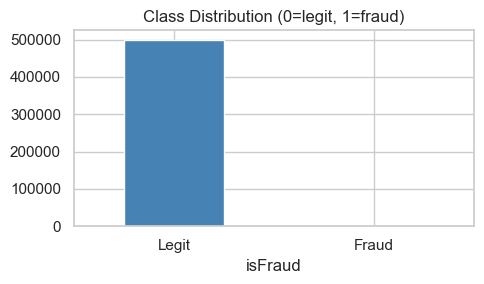

In [2]:
fraud_rate = df['isFraud'].mean()
print(f'Fraud rate: {fraud_rate:.4%}')
print(df['isFraud'].value_counts())

fig, ax = plt.subplots(figsize=(5, 3))
df['isFraud'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution (0=legit, 1=fraud)')
ax.set_xticklabels(['Legit', 'Fraud'], rotation=0)
plt.tight_layout()
plt.savefig('../docs/class_distribution.png', dpi=120)
plt.show()

## 2. Transaction Types — Where Does Fraud Hide?

In [3]:
type_fraud = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean'])
type_fraud.columns = ['n_fraud', 'n_total', 'fraud_rate']
type_fraud = type_fraud.sort_values('fraud_rate', ascending=False)
print(type_fraud)
# Key insight: fraud only in TRANSFER and CASH_OUT

          n_fraud  n_total  fraud_rate
type                                  
TRANSFER      112    40730      0.0027
CASH_OUT      121   182316      0.0007
CASH_IN         0   109319      0.0000
DEBIT           0     3603      0.0000
PAYMENT         0   164032      0.0000


## 3. Amount Distribution by Class

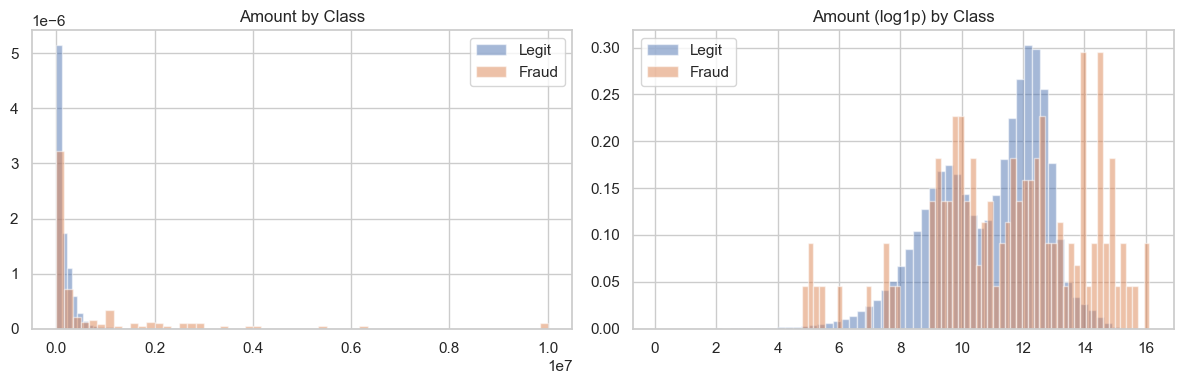

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, log in zip(axes, [False, True]):
    for label, grp in df.groupby('isFraud'):
        vals = np.log1p(grp['amount']) if log else grp['amount']
        ax.hist(vals, bins=60, alpha=0.5, label='Fraud' if label else 'Legit', density=True)
    ax.set_title(f'Amount{" (log1p)" if log else ""} by Class')
    ax.legend()
plt.tight_layout()
plt.savefig('../docs/amount_distribution.png', dpi=120)
plt.show()

## 4. Engineered Features — Balance Diffs

In [5]:
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

for feat in ['balance_diff_orig', 'balance_diff_dest', 'amount']:
    corr = df[feat].corr(df['isFraud'])
    print(f'{feat}: corr with isFraud = {corr:.4f}')

balance_diff_orig: corr with isFraud = 0.1435
balance_diff_dest: corr with isFraud = 0.0121
amount: corr with isFraud = 0.0528


## 5. Null Check

In [6]:
nulls = df.isnull().sum()
assert nulls.sum() == 0, f'Unexpected nulls: {nulls[nulls > 0]}'
print('No nulls found — PaySim is clean synthetic data.')

No nulls found — PaySim is clean synthetic data.


## 6. Metric Decision

**Chosen metric: F2 score** `= (5 * P * R) / (4P + R)`

- Fraud rate ~0.13% → accuracy is useless (majority-class baseline = 99.87%)
- Missed fraud (false negative) costs far more than a false alarm (false positive)
- F2 weights recall twice as heavily as precision, encoding this cost asymmetry
- AUC-ROC is misleading under extreme imbalance; average precision (AUC-PR) is better for model selection
- **Promotion threshold**: F2 ≥ 0.70 on held-out test set
- Threshold tuning: sweep 0.01–0.99 and pick the threshold that maximises F2 on the validation fold

In [7]:
from sklearn.metrics import fbeta_score
y_true = df['isFraud']
# Majority-class baseline: predict nothing is fraud
y_pred_majority = np.zeros(len(y_true), dtype=int)
baseline_f2 = fbeta_score(y_true, y_pred_majority, beta=2, zero_division=0)
print(f'Majority-class baseline F2 = {baseline_f2:.4f}  (floor to beat)')

Majority-class baseline F2 = 0.0000  (floor to beat)
